<a href="https://colab.research.google.com/github/rameshjayamani-oss/GenAI_Assignment/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np

# Original data
original_loan_data = {
    'Age': [28, 45, 35, 50, 30, 42, 26, 48, 38, 55],
    'AnnualIncome(lakhs)': [6.5, 12, 8, 15, 7, 10, 5.5, 14, 9, 16],
    'CreditScore(300-900)': [720, 680, 750, 640, 710, 660, 730, 650, 700, 620],
    'LoanAmount(lakhs)': [5, 10, 6, 12, 5, 9, 4, 11, 7, 13],
    'LoanTerm(years)': [5, 10, 7, 15, 5, 10, 4, 12, 8, 15],
    'EmploymentType': ['Salaried', 'Self-Employed', 'Salaried', 'Self-Employed', 'Salaried',
                       'Salaried', 'Salaried', 'Self-Employed', 'Salaried', 'Self-Employed'],
    'loan(yes/no)': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}

original_loan_df = pd.DataFrame(original_loan_data)

np.random.seed(42)

synthetic_loan_records = []

for _ in range(40):

    age = np.random.randint(25, 61)

    # Income loosely correlated with age plus noise
    annual_income = round(np.clip(np.random.normal(0.25 * age, 3), 4, 17), 2)

    # Credit score centered around 680-720 with randomness
    credit_score = int(np.clip(np.random.normal(700, 50), 300, 900))

    # Employment type: roughly 60% Salaried, 40% Self-Employed (based on your data)
    employment_type = np.random.choice(['Salaried', 'Self-Employed'], p=[0.6, 0.4])

    # Loan amount depends on income and credit score (better credit = higher loan)
    loan_amount_base = annual_income * 0.6
    loan_amount_noise = np.random.normal(0, 1)
    loan_amount = round(np.clip(loan_amount_base + loan_amount_noise, 3, 15), 2)

    # Loan term 4-15 years, more likely longer if loan amount higher
    if loan_amount > 10:
        loan_term = np.random.randint(8, 16)
    else:
        loan_term = np.random.randint(4, 11)

    # Loan approval (1 or 0), more likely if better credit score and salaried
    loan_prob = 0.3
    if credit_score > 700:
        loan_prob += 0.4
    if employment_type == 'Salaried':
        loan_prob += 0.2

    loan = np.random.choice([0,1], p=[1-loan_prob, loan_prob])

    synthetic_loan_records.append([
        age,
        annual_income,
        credit_score,
        loan_amount,
        loan_term,
        employment_type,
        loan
    ])

synthetic_loan_df = pd.DataFrame(
    synthetic_loan_records,
    columns=['Age', 'AnnualIncome(lakhs)', 'CreditScore(300-900)', 'LoanAmount(lakhs)', 'LoanTerm(years)', 'EmploymentType', 'loan(yes/no)']
)


# Combine original and synthetic
final_loan_df = pd.concat([original_loan_df, synthetic_loan_df], ignore_index=True)
#print(synthetic_loan_df['EmploymentType'].unique())
final_loan_df
#print(original_loan_df['EmploymentType'].head())
#print(synthetic_loan_df['EmploymentType'].head(30))


,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),EmploymentType,loan(yes/no)
0,28,6.50,720,5.00,5,Salaried,0
1,45,12.00,680,10.00,10,Self-Employed,1
2,35,8.00,750,6.00,7,Salaried,0
3,50,15.00,640,12.00,15,Self-Employed,1
4,30,7.00,710,5.00,5,Salaried,0
5,42,10.00,660,9.00,10,Salaried,1
6,26,5.50,730,4.00,4,Salaried,0
7,48,14.00,650,11.00,12,Self-Employed,1
8,38,9.00,700,7.00,8,Salaried,0
9,55,16.00,620,13.00,15,Self-Employed,1


In [44]:
print(final_loan_df.columns)
print(final_loan_df['EmploymentType'].head(10))


Index(['Age', 'AnnualIncome(lakhs)', 'CreditScore(300-900)',
       'LoanAmount(lakhs)', 'LoanTerm(years)', 'EmploymentType',
       'loan(yes/no)'],
      dtype='object')
0    1
1    0
2    1
3    0
4    1
5    1
6    1
7    0
8    1
9    0
Name: EmploymentType, dtype: int64


In [41]:

final_loan_df['EmploymentType'] = final_loan_df['EmploymentType'].map({'Salaried': 1, 'Self-Employed': 0})
print(final_loan_df[['EmploymentType']].head(20))



    EmploymentType
0                1
1                0
2                1
3                0
4                1
5                1
6                1
7                0
8                1
9                0
10               1
11               1
12               1
13               1
14               1
15               0
16               1
17               0
18               0
19               0


In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
features = final_loan_df[['Age', 'AnnualIncome(lakhs)', 'CreditScore(300-900)', 'LoanAmount(lakhs)', 'LoanTerm(years)', 'EmploymentType']]
target = final_loan_df['loan(yes/no)']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

feature_train, feature_test, target_train, target_test = train_test_split(
    features_scaled,
    target,
    test_size=0.3,
    random_state=827
)
kModel = KNeighborsClassifier(n_neighbors=3)
kModel.fit(feature_train, target_train)
print("KNN model trained successfully.")

# Make predictions on the test set
target_pred = kModel.predict(feature_test)

# Evaluate the model
print("\nClassification Report:")
print(classification_report(target_test, target_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(target_test, target_pred))


KNN model trained successfully.

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         6
           1       0.64      0.78      0.70         9

    accuracy                           0.60        15
   macro avg       0.57      0.56      0.55        15
weighted avg       0.58      0.60      0.58        15


Confusion Matrix:
[[2 4]
 [2 7]]


In [55]:
dtModel = DecisionTreeClassifier(random_state=827)
dtModel.fit(feature_train, target_train)
print("DT model trained successfully.")

# Make predictions on the test set
target_pred = dtModel.predict(feature_test)

# Evaluate the model
print("\nClassification Report:")
print(classification_report(target_test, target_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(target_test, target_pred))

DT model trained successfully.

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.67      0.67      0.67         9

    accuracy                           0.60        15
   macro avg       0.58      0.58      0.58        15
weighted avg       0.60      0.60      0.60        15


Confusion Matrix:
[[3 3]
 [3 6]]


Text(0.5, 1.0, 'Confusion Matrix for DT')

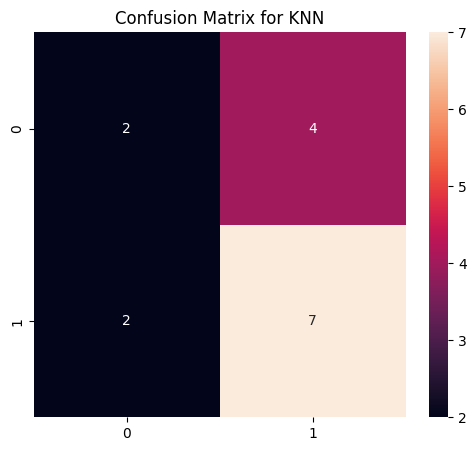

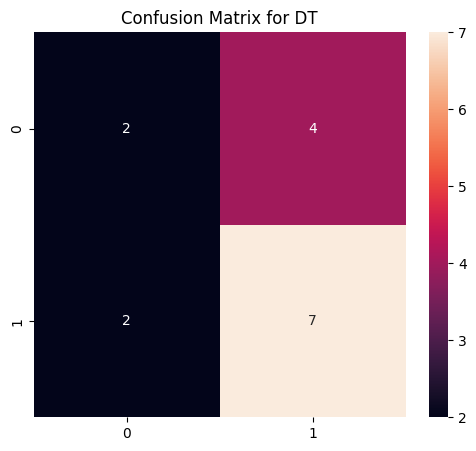

In [48]:
target_predicted = kModel.predict(feature_test)
kCm = confusion_matrix(target_test, target_predicted)
plt.figure(figsize=(6, 5))
sns.heatmap(kCm, annot=True)
plt.title('Confusion Matrix for KNN')

target_predicted = dtModel.predict(feature_test)
dtCm = confusion_matrix(target_test, target_predicted)
plt.figure(figsize=(6, 5))
sns.heatmap(kCm, annot=True)
plt.title('Confusion Matrix for DT')

Here’s an interpretation and comparison based on the results of your KNN and Decision Tree (DT) models:

1. Identify high-risk customers
Both models aim to identify customers likely to default (Class 1).

KNN: More sensitive, with higher recall for default (0.78), meaning it catches more actual defaulters (7 out of 9), but at cost of more false positives (4 wrongly flagged non-defaulters).
DT: Balanced recall and precision (~0.67) for defaults, catching fewer true defaulters (6) but also fewer false positives.
2. What patterns lead to loan default?
Typical predictive factors are:

Lower Credit Score
Lower or unstable Annual Income
Higher Loan Amount relative to income
Employment type (e.g., self-employed may carry more risk)
Longer Loan Term could imply higher risk for default
Both models likely learned these patterns to varying degrees, with DT possibly capturing clearer decision boundaries.

3. How do credit score and income influence predictions?
Higher credit score and higher income generally decrease default risk.
Lower scores/income increase predicted default risk.
Both models use these features but DT can handle feature importance and interactions more explicitly.
4. Suggest banking policies based on model output
Use model predictions to flag potential defaulters for manual review.
Provide targeted financial advice or modified loan terms to flagged customers.
Minimize false positives (customers wrongly flagged), especially in KNN, to avoid customer dissatisfaction.
Incorporate more data and improve models to raise accuracy above 60%.
5. Compare KNN with Decision Trees for this problem
KNN: Instance-based, sensitive to scaling and dominated by strong features like Loan Amount if not normalized. Computationally heavy at prediction time.
Decision Tree: More interpretable, faster predictions, handles non-linear relationships and feature interactions better, less sensitive to scaling.
Here, DT shows slightly better balanced performance overall.
6. What happens if LoanAmount dominates distance calculation?
In KNN, if Loan Amount has a larger scale/range, it skews distance calculations, making nearest neighbors biased toward that feature and ignoring others.
Proper feature scaling (e.g., normalization or standardization) is essential to avoid this and ensure balanced influence.
7. Should KNN be used in real-time loan approval systems?
Generally no, because:

Prediction speed slows as data grows (KNN needs to calculate distances to all training points).
Sensitive to noisy features and unscaled data.
Models like Decision Trees or ensemble methods are more efficient and interpretable for real-time decisions.